# AI-gen descriptions vs. drawings (Bainbridge/Wilma 2019) - object counts

Compares how many **objects** people mention in the `aigen` conditions with how many objects
they *drew* in the 2019 drawing study, across the same three memory tasks
(perception / immediate memory / delayed memory).

- **aigen** source: `<processed_dir>/nlp_analysis/trials_final_semantic_tags.csv` per condition;
  the `objects` column is a stringified list, its length is the count.
- **drawings** source: `Data/other_datasets/wilmas_drawings_2019/wilmas_data_2019.csv`
  (`category, condition, count`) - already-aggregated **means** (objects per drawing), one number
  per condition, so they carry no error bars here.

**Caveat.** These are two different modalities from two different studies: an object *drawn*
and an object *named in a description* are not the same unit, and the drawing numbers are
group means we cannot re-derive spread for. Read the bars as a rough level comparison of how
much scene content survives each memory task, not as a like-for-like statistical test.

All views are **bar charts**, as requested.

In [7]:
import sys
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

# Find project root (the dir containing config.py) regardless of where the notebook sits.
project_root = Path.cwd()
while not (project_root / "config.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config
print("project root:", project_root)

project root: /mnt/hdd/anatkorol/Imagination_in_translation


In [8]:
# --- aigen semantic tags -----------------------------------------------------
SEM_FILE = "trials_final_semantic_tags.csv"
GEN = "aigen"


def _count(cell):
    """Length of a stringified list cell; 0 for empty / NaN / unparseable."""
    if pd.isna(cell):
        return 0
    try:
        val = ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        return 0
    return len(val) if isinstance(val, (list, tuple)) else 0


frames = []
for c in config.GROUPS_BY_GEN[GEN]:
    p = config.paths_for(c).processed_dir / "nlp_analysis" / SEM_FILE
    if not p.exists():
        print(f"skip {c}: {SEM_FILE} not found ({p})")
        continue
    d = pd.read_csv(p)
    cm = config.mapping_data["CONDITIONS"][c]
    d["condition"], d["generation"], d["task"] = c, cm["generation"], cm["task"]
    d["n_objects"] = d["objects"].apply(_count)
    frames.append(d)
    print(f"loaded {c}: {len(d)} rows, {d['uid'].nunique()} participants")

aigen = pd.concat(frames, ignore_index=True)
assert not aigen.empty, f"no {SEM_FILE} found for any {GEN} condition"
aigen["attempt"] = aigen["attempt"].astype(int)
aigen.groupby(["task", "attempt"]).size().unstack("attempt")

loaded aigen_perc: 279 rows, 20 participants
loaded aigen_imm: 327 rows, 23 participants
loaded aigen_del: 297 rows, 23 participants


attempt,1,2,3
task,,,
delay,99,99,99
immediate,109,109,109
perception,93,93,93


In [9]:
# --- drawings (2019) ---------------------------------------------------------
DRAWINGS_CSV = config.ROOT / "Data" / "other_datasets" / "wilmas_drawings_2019" / "wilmas_data_2019.csv"

# The drawings file names its conditions in prose; map them onto our task slugs.
DRAW_TASK = {"perception": "perception", "immediate memory": "immediate", "delayed memory": "delay"}

draw = pd.read_csv(DRAWINGS_CSV)
draw["condition"] = draw["condition"].str.strip().str.lower()
draw = draw[draw["category"].str.strip().str.lower() == "objects"].copy()
draw["task"] = draw["condition"].map(DRAW_TASK)
assert draw["task"].notna().all(), f"unmapped drawing conditions: {draw.loc[draw['task'].isna(), 'condition'].tolist()}"
draw = draw[["task", "count"]].rename(columns={"count": "drawn_objects"})
draw

,task,drawn_objects
0,perception,9.4
1,immediate,7.8
2,delay,7.0


In [10]:
# --- Style + fixed colors ----------------------------------------------------
sns.set_theme(style="whitegrid")

TASK_ORDER  = ["perception", "immediate", "delay"]
TASK_LABELS = {"perception": "Perception", "immediate": "Immediate memory", "delay": "Delayed memory"}
ATTEMPTS    = [1, 2, 3]

# aigen keeps its Dark2 green from the cross-generation notebooks; drawings get a neutral grey.
SRC_COLORS = {"aigen": "#1b9e77", "drawings": "#7f7f7f"}
SRC_LABELS = {"aigen": "AI-gen descriptions", "drawings": "Drawings (2019)"}
# Same green, light -> dark, one shade per attempt.
ATTEMPT_COLORS = {1: "#a6dbc8", 2: "#5cbb9c", 3: "#1b9e77"}

GRAPHS = (config.ROOT / "analysis" / "outputs" / config.DATASET / "combined" / "graphs"
          / "drawings_comparison")
GRAPHS.mkdir(parents=True, exist_ok=True)
print("saving figures to:", GRAPHS)

saving figures to: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/drawings_comparison


In [11]:
# --- Per-participant object counts (the unit for every aigen bar) ------------
def ppt_attempt_means():
    """Mean object count per (task, uid, attempt), collapsing sessions / GT images."""
    return (aigen.groupby(["task", "uid", "attempt"], as_index=False)["n_objects"]
                 .mean().rename(columns={"n_objects": "count"}))


def ppt_means():
    """Mean object count per (task, uid), collapsing attempts as well."""
    return (ppt_attempt_means().groupby(["task", "uid"], as_index=False)["count"].mean())


ppt = ppt_means()
summary = (ppt.groupby("task")["count"].agg(["mean", "sem", "count"])
              .reindex(TASK_ORDER)
              .join(draw.set_index("task")["drawn_objects"]))
summary["diff (aigen - drawings)"] = summary["mean"] - summary["drawn_objects"]
summary.rename(columns={"count": "n_participants"})

,mean,sem,n_participants,drawn_objects,diff (aigen - drawings)
task,,,,,
perception,10.345278,0.942581,20,9.4,0.945278
immediate,6.525845,0.733527,23,7.8,-1.274155
delay,6.614251,0.612919,23,7.0,-0.385749


## View 1 - aigen vs drawings, by task
One bar pair per task: mean objects named in the AI-gen descriptions (participant means, +/- SE,
faint points = individual participants) beside the mean objects drawn in 2019. The drawings bar
is a published group mean, so it has no error bar.

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/drawings_comparison/aigen_vs_drawings_objects_by_task.png


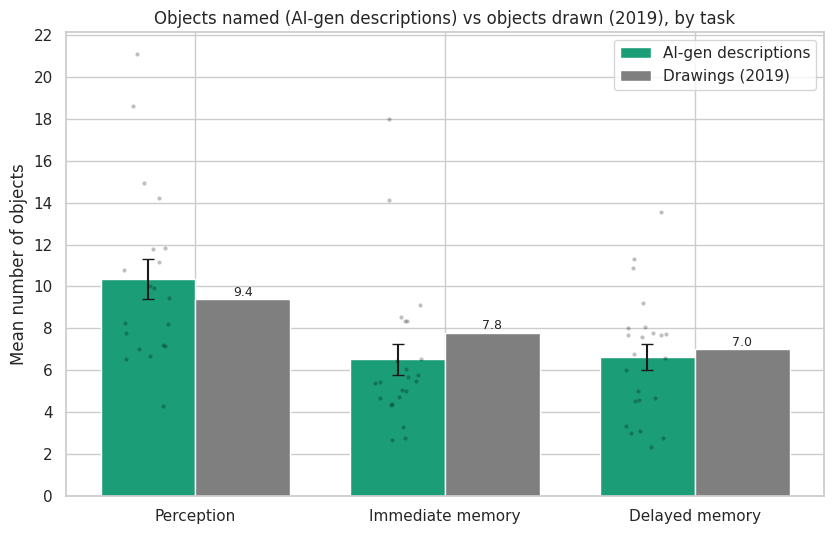

In [12]:
def plot_aigen_vs_drawings(save=True):
    ppt = ppt_means()
    bars = (ppt.groupby("task")["count"].agg(["mean", "sem"]).reindex(TASK_ORDER)
               .join(draw.set_index("task")["drawn_objects"]))

    x = np.arange(len(TASK_ORDER))
    w = 0.38
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.bar(x - w / 2, bars["mean"], w, yerr=bars["sem"], capsize=4,
           color=SRC_COLORS["aigen"], label=SRC_LABELS["aigen"])
    ax.bar(x + w / 2, bars["drawn_objects"], w,
           color=SRC_COLORS["drawings"], label=SRC_LABELS["drawings"])

    # Individual participants behind the aigen bar.
    rng = np.random.default_rng(0)
    for i, task in enumerate(TASK_ORDER):
        v = ppt.loc[ppt["task"] == task, "count"].to_numpy()
        ax.scatter(np.full(len(v), x[i] - w / 2) + rng.uniform(-w / 4, w / 4, len(v)), v,
                   s=9, color="black", alpha=0.25, linewidth=0, zorder=3)

    for i, task in enumerate(TASK_ORDER):
        ax.text(x[i] + w / 2, bars.loc[task, "drawn_objects"] + 0.15,
                f"{bars.loc[task, 'drawn_objects']:.1f}", ha="center", fontsize=9)

    ax.set_xticks(x); ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER])
    ax.set_ylabel("Mean number of objects")
    ax.yaxis.set_major_locator(MultipleLocator(2))   # ticks every 2 objects
    ax.set_title("Objects named (AI-gen descriptions) vs objects drawn (2019), by task")
    ax.legend(frameon=True)
    fig.tight_layout()
    if save:
        out = GRAPHS / "aigen_vs_drawings_objects_by_task.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()


plot_aigen_vs_drawings()

## View 2 - aigen split by attempt, against the drawings level
The drawing study had a single production per image; our participants describe the same image up
to three times with feedback. Here each attempt gets its own bar (light -> dark green), with the
2019 drawing mean as a grey bar and a dashed reference line per task, so you can see whether
iterating pushes the descriptions above or below the drawing level.

In [ ]:
def plot_by_attempt_vs_drawings(save=True):
    pa = ppt_attempt_means()
    bars = pa.groupby(["task", "attempt"])["count"].agg(["mean", "sem"])

    x = np.arange(len(TASK_ORDER))
    w = 0.2
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    for j, a in enumerate(ATTEMPTS):
        off = (j - 1.5) * w
        m = [bars.loc[(t, a), "mean"] if (t, a) in bars.index else np.nan for t in TASK_ORDER]
        e = [bars.loc[(t, a), "sem"] if (t, a) in bars.index else np.nan for t in TASK_ORDER]
        ax.bar(x + off, m, w, yerr=e, capsize=3, color=ATTEMPT_COLORS[a], label=f"AI-gen attempt {a}")

    dvals = draw.set_index("task")["drawn_objects"].reindex(TASK_ORDER)
    ax.bar(x + 1.5 * w, dvals, w, color=SRC_COLORS["drawings"], label=SRC_LABELS["drawings"])
    for i, task in enumerate(TASK_ORDER):
        ax.hlines(dvals[task], x[i] - 2 * w, x[i] + 2 * w, color="black", ls="--", lw=1, zorder=4)

    ax.set_xticks(x); ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER])
    ax.set_ylabel("Mean number of objects")
    ax.yaxis.set_major_locator(MultipleLocator(2))   # ticks every 2 objects
    ax.set_title("Objects per attempt vs the 2019 drawing level (participant means +/- SE)")
    ax.legend(frameon=True, ncol=2)
    fig.tight_layout()
    if save:
        out = GRAPHS / "aigen_attempts_vs_drawings_objects.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()


plot_by_attempt_vs_drawings()

## View 3 - gap to the drawings baseline
Difference bars: participant mean objects named minus the 2019 drawn-object mean for the same
task (positive = descriptions carry more objects than drawings). Error bars are the SE of the
aigen participant means; the drawing value is treated as a fixed constant.

In [ ]:
def plot_gap_to_drawings(save=True):
    ppt = ppt_means().merge(draw, on="task")
    ppt["gap"] = ppt["count"] - ppt["drawn_objects"]
    bars = ppt.groupby("task")["gap"].agg(["mean", "sem"]).reindex(TASK_ORDER)

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.bar(np.arange(len(TASK_ORDER)), bars["mean"], 0.55, yerr=bars["sem"], capsize=4,
           color=SRC_COLORS["aigen"])
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.set_xticks(np.arange(len(TASK_ORDER)))
    ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER])
    ax.set_ylabel("delta objects\n(AI-gen named - 2019 drawn)")
    ax.set_title("How far the descriptions sit above the drawing baseline")
    fig.tight_layout()
    if save:
        out = GRAPHS / "aigen_minus_drawings_objects_gap.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()


plot_gap_to_drawings()

## View 4 - normalised to perception
Both studies show the same qualitative pattern (fewer items the further from perception), but on
different absolute scales. Dividing each source by its own perception value removes the scale and
compares the *shape* of the memory drop-off directly.

In [ ]:
def plot_normalised_to_perception(save=True):
    a = ppt_means().groupby("task")["count"].mean().reindex(TASK_ORDER)
    d = draw.set_index("task")["drawn_objects"].reindex(TASK_ORDER)
    norm = pd.DataFrame({"aigen": a / a["perception"], "drawings": d / d["perception"]})

    x = np.arange(len(TASK_ORDER))
    w = 0.38
    fig, ax = plt.subplots(figsize=(8.0, 5.0))
    for k, src in enumerate(["aigen", "drawings"]):
        ax.bar(x + (k - 0.5) * w, norm[src], w, color=SRC_COLORS[src], label=SRC_LABELS[src])
        for i, t in enumerate(TASK_ORDER):
            ax.text(x[i] + (k - 0.5) * w, norm[src][t] + 0.015, f"{norm[src][t]:.2f}",
                    ha="center", fontsize=8)
    ax.axhline(1.0, color="black", ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER])
    ax.set_ylabel("Objects relative to perception (= 1.0)")
    ax.set_title("Shape of the memory drop-off, each source scaled to its own perception mean")
    ax.legend(frameon=True)
    fig.tight_layout()
    if save:
        out = GRAPHS / "aigen_vs_drawings_objects_normalised.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()
    return norm


plot_normalised_to_perception()

---
### Notes / extending this
- The drawings CSV currently holds only the `objects` category. If the other semantic categories
  (`stuff`, `scene_category`, ...) are ever added as extra rows, the loading cell already filters
  on `category`, so only that filter and the plotted column need to change.
- To compare `nogen` / `plain` against the drawings too, swap `GEN` for a list and add a source
  colour - the plotting helpers group by `task` only, so the change is local.
- No statistics are run here on purpose: the drawings side is a set of published means without
  per-participant data, so a test would need their raw counts.